In [ ]:
import pandas as pd
from transformers import pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split

def load_dataset(filepath):
    # Assumes the dataset has columns 'text' and 'label'
    df = pd.read_csv('/content/updated_with_relevance.csv')
    return df

def train_classifier(texts, labels):
    vectorizer = CountVectorizer()
    classifier = MultinomialNB()
    model = make_pipeline(vectorizer, classifier)
    model.fit(texts, labels)
    return model

def categorize_texts(model, texts):
    return model.predict(texts)

if __name__ == "__main__":

    filepath = 'path/to/your/dataset.csv'
    df = load_dataset(filepath)

    # dataset should have the text and label columns
    if 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Dataset must contain 'text' and 'label' columns")

    texts = df['text']
    labels = df['label']

    # train-test split, 80%-20%
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

    model = train_classifier(X_train, y_train)

    categories = categorize_texts(model, X_test)

    for text, category in zip(X_test, categories):
        print(f"Text: {text}")
        print(f"Predicted Category: {category}")
        print()

Text: @slgrnwood up http://t.co/KJOqoZWME4 and onto
Predicted Category: casualties_and_public_impact

Text: What is current situation of India, ceasefire violation on border, gangrapes in all our country, flood in half country but no relief?
Predicted Category: crisis_specific_information

Text: Nepal flood toll hits 101, fears of disease rise http://t.co/DtXNZESUqD #india
Predicted Category: casualties_and_public_impact

Text: #MaikyLinaresHere Scores Killed in Flooding in Nepal and India: More than 11,000 homes have been damaged and r... http://t.co/wKS21CgzOb
Predicted Category: casualties_and_public_impact

Text: RT @PharmaIQ: Fleeing India: What Will Make Clinical Trials Flood Back: India‚Äôs clinical trial industry has seen it ... http://t.co/2eixq4p‚Ä¶
Predicted Category: non_informative

Text: @PMOIndia Last yr after d heavy floods I predicted t8 if d desiltation wk is n8 done immed then next yr even small rain wil bring doom in UP
Predicted Category: non_informative

Text: I w

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def load_dataset(filepath):
    # ideally the dataset has columns 'text' and 'label'
    df = pd.read_csv('/content/updated_with_relevance.csv')
    return df

def train_classifier(texts, labels):
    vectorizer = CountVectorizer()
    classifier = MultinomialNB()
    model = make_pipeline(vectorizer, classifier)
    model.fit(texts, labels)
    return model

def categorize_texts(model, texts):
    return model.predict(texts)

if __name__ == "__main__":
    filepath = '/content/updated_with_relevance.csv'
    df = load_dataset(filepath)

    if 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Dataset must contain 'text' and 'label' columns")

    texts = df['text']
    labels = df['label']

    # train-test split, 80-20
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

    model = train_classifier(X_train, y_train)

    predictions = categorize_texts(model, X_test)

    report = classification_report(y_test, predictions, output_dict=True, zero_division=1)

    # binarizing the labels for calculating ROC AUC
    classes = sorted(set(y_train))
    y_test_binarized = label_binarize(y_test, classes=classes)
    predictions_proba = model.predict_proba(X_test)

    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), np.hstack(predictions_proba), pos_label=1)
    roc_auc = auc(fpr, tpr)

    print("Classification Report:")

    accuracy = report.get('accuracy', None)
    macro_f1 = report.get('macro avg', {}).get('f1-score', None)
    micro_f1 = report.get('micro avg', {}).get('f1-score', None)
    weighted_f1 = report.get('weighted avg', {}).get('f1-score', None)
    macro_precision = report.get('macro avg', {}).get('precision', None)
    micro_precision = report.get('micro avg', {}).get('precision', None)
    weighted_precision = report.get('weighted avg', {}).get('precision', None)

    if accuracy is not None:
        print(f"Accuracy: {accuracy * 100:.2f}%")
    else:
        print("Accuracy: N/A")

    if isinstance(macro_f1, (int, float)):
        print(f"F1 Score (Macro): {macro_f1 * 100:.2f}%")
    else:
        print("F1 Score (Macro): N/A")

    if isinstance(micro_f1, (int, float)):
        print(f"F1 Score (Micro): {micro_f1 * 100:.2f}%")
    else:
        print("F1 Score (Micro): N/A")

    if isinstance(weighted_f1, (int, float)):
        print(f"F1 Score (Weighted): {weighted_f1 * 100:.2f}%")
    else:
        print("F1 Score (Weighted): N/A")

    if isinstance(macro_precision, (int, float)):
        print(f"Precision (Macro): {macro_precision * 100:.2f}%")
    else:
        print("Precision (Macro): N/A")

    if isinstance(micro_precision, (int, float)):
        print(f"Precision (Micro): {micro_precision * 100:.2f}%")
    else:
        print("Precision (Micro): N/A")

    if isinstance(weighted_precision, (int, float)):
        print(f"Precision (Weighted): {weighted_precision * 100:.2f}%")
    else:
        print("Precision (Weighted): N/A")

    print(f"ROC AUC: {roc_auc:.2f}")


Classification Report:
Accuracy: 77.63%
F1 Score (Macro): 45.49%
F1 Score (Micro): N/A
F1 Score (Weighted): 74.21%
Precision (Macro): 76.58%
Precision (Micro): N/A
Precision (Weighted): 77.70%
ROC AUC: 0.95


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments

def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

def prepare_data(df):
    return df['text'].tolist(), df['label'].tolist()

def tokenize_data(texts, labels):
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    tokens = tokenizer(texts, padding=True, truncation=True, return_tensors='pt')
    return tokens, labels

def train_classifier(train_tokens, train_labels):
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(set(train_labels)))
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=8,
        evaluation_strategy="epoch",
        logging_dir='./logs',
    )
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tokens,
        eval_dataset=train_tokens,
    )
    trainer.train()
    return model

if __name__ == "__main__":
    filepath = '/content/updated_with_relevance.csv'
    df = load_dataset(filepath)

    texts, labels = prepare_data(df)

    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

    train_tokens, train_labels = tokenize_data(X_train, y_train)
    test_tokens, test_labels = tokenize_data(X_test, y_test)

    model = train_classifier(train_tokens, train_labels)

    with torch.no_grad():
        outputs = model(**test_tokens)
        predictions = torch.argmax(outputs.logits, dim=1).numpy()

    report = classification_report(y_test, predictions, output_dict=True, zero_division=1)

    classes = sorted(set(y_train))
    y_test_binarized = label_binarize(y_test, classes=classes)
    predictions_proba = torch.softmax(outputs.logits, dim=1).numpy()

    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), np.hstack(predictions_proba), pos_label=1)
    roc_auc = auc(fpr, tpr)

    print("Classification Report:")
    print(report)

    print(f"ROC AUC: {roc_auc:.2f}")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

def train_classifier(texts, labels):
    vectorizer = CountVectorizer()
    classifier = MultinomialNB()
    model = make_pipeline(vectorizer, classifier)
    model.fit(texts, labels)
    return model

def categorize_texts(model, texts):
    return model.predict(texts)

if __name__ == "__main__":
    filepath = '/content/updated_with_relevance.csv'
    df = load_dataset(filepath)

    if 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Dataset must contain 'text' and 'label' columns")

    texts = df['text']
    labels = df['label']

    X_temp, X_test, y_temp, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

    model = train_classifier(X_train, y_train)

    val_predictions = categorize_texts(model, X_val)

    val_report = classification_report(y_val, val_predictions, output_dict=True, zero_division=1)

    test_predictions = categorize_texts(model, X_test)

    test_report = classification_report(y_test, test_predictions, output_dict=True, zero_division=1)

    classes = sorted(set(y_train))
    y_test_binarized = label_binarize(y_test, classes=classes)
    predictions_proba = model.predict_proba(X_test)

    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), np.hstack(predictions_proba), pos_label=1)
    roc_auc = auc(fpr, tpr)

    print("Validation Classification Report:")

    accuracy_val = val_report.get('accuracy', None)
    macro_f1_val = val_report.get('macro avg', {}).get('f1-score', None)
    micro_f1_val = val_report.get('micro avg', {}).get('f1-score', None)
    weighted_f1_val = val_report.get('weighted avg', {}).get('f1-score', None)
    macro_precision_val = val_report.get('macro avg', {}).get('precision', None)
    micro_precision_val = val_report.get('micro avg', {}).get('precision', None)
    weighted_precision_val = val_report.get('weighted avg', {}).get('precision', None)

    if accuracy_val is not None:
        print(f"Validation Accuracy: {accuracy_val * 100:.2f}%")
    else:
        print("Validation Accuracy: N/A")

    if isinstance(macro_f1_val, (int, float)):
        print(f"Validation F1 Score (Macro): {macro_f1_val * 100:.2f}%")
    else:
        print("Validation F1 Score (Macro): N/A")

    if isinstance(micro_f1_val, (int, float)):
        print(f"Validation F1 Score (Micro): {micro_f1_val * 100:.2f}%")
    else:
        print("Validation F1 Score (Micro): N/A")

    if isinstance(weighted_f1_val, (int, float)):
        print(f"Validation F1 Score (Weighted): {weighted_f1_val * 100:.2f}%")
    else:
        print("Validation F1 Score (Weighted): N/A")

    if isinstance(macro_precision_val, (int, float)):
        print(f"Validation Precision (Macro): {macro_precision_val * 100:.2f}%")
    else:
        print("Validation Precision (Macro): N/A")

    if isinstance(micro_precision_val, (int, float)):
        print(f"Validation Precision (Micro): {micro_precision_val * 100:.2f}%")
    else:
        print("Validation Precision (Micro): N/A")

    if isinstance(weighted_precision_val, (int, float)):
        print(f"Validation Precision (Weighted): {weighted_precision_val * 100:.2f}%")
    else:
        print("Validation Precision (Weighted): N/A")

    print("\nTest Classification Report:")

    accuracy_test = test_report.get('accuracy', None)
    macro_f1_test = test_report.get('macro avg', {}).get('f1-score', None)
    micro_f1_test = test_report.get('micro avg', {}).get('f1-score', None)
    weighted_f1_test = test_report.get('weighted avg', {}).get('f1-score', None)
    macro_precision_test = test_report.get('macro avg', {}).get('precision', None)
    micro_precision_test = test_report.get('micro avg', {}).get('precision', None)
    weighted_precision_test = test_report.get('weighted avg', {}).get('precision', None)

    if accuracy_test is not None:
        print(f"Test Accuracy: {accuracy_test * 100:.2f}%")
    else:
        print("Test Accuracy: N/A")

    if isinstance(macro_f1_test, (int, float)):
        print(f"Test F1 Score (Macro): {macro_f1_test * 100:.2f}%")
    else:
        print("Test F1 Score (Macro): N/A")

    if isinstance(micro_f1_test, (int, float)):
        print(f"Test F1 Score (Micro): {micro_f1_test * 100:.2f}%")
    else:
        print("Test F1 Score (Micro): N/A")

    if isinstance(weighted_f1_test, (int, float)):
        print(f"Test F1 Score (Weighted): {weighted_f1_test * 100:.2f}%")
    else:
        print("Test F1 Score (Weighted): N/A")

    if isinstance(macro_precision_test, (int, float)):
        print(f"Test Precision (Macro): {macro_precision_test * 100:.2f}%")
    else:
        print("Test Precision (Macro): N/A")

    if isinstance(micro_precision_test, (int, float)):
        print(f"Test Precision (Micro): {micro_precision_test * 100:.2f}%")
    else:
        print("Test Precision (Micro): N/A")

    if isinstance(weighted_precision_test, (int, float)):
        print(f"Test Precision (Weighted): {weighted_precision_test * 100:.2f}%")
    else:
        print("Test Precision (Weighted): N/A")

    print(f"\nROC AUC: {roc_auc:.2f}")


Validation Classification Report:
Validation Accuracy: 71.40%
Validation F1 Score (Macro): 36.74%
Validation F1 Score (Micro): N/A
Validation F1 Score (Weighted): 66.24%
Validation Precision (Macro): 85.73%
Validation Precision (Micro): N/A
Validation Precision (Weighted): 77.45%

Test Classification Report:
Test Accuracy: 76.48%
Test F1 Score (Macro): 52.92%
Test F1 Score (Micro): N/A
Test F1 Score (Weighted): 74.30%
Test Precision (Macro): 73.28%
Test Precision (Micro): N/A
Test Precision (Weighted): 77.07%

ROC AUC: 0.95


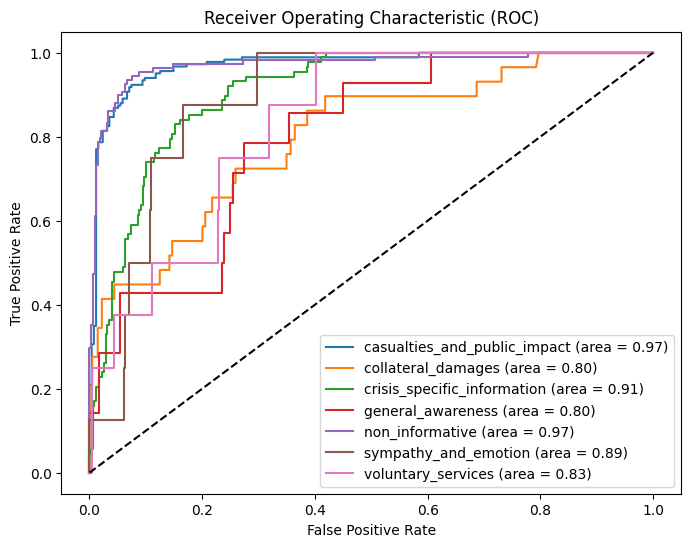

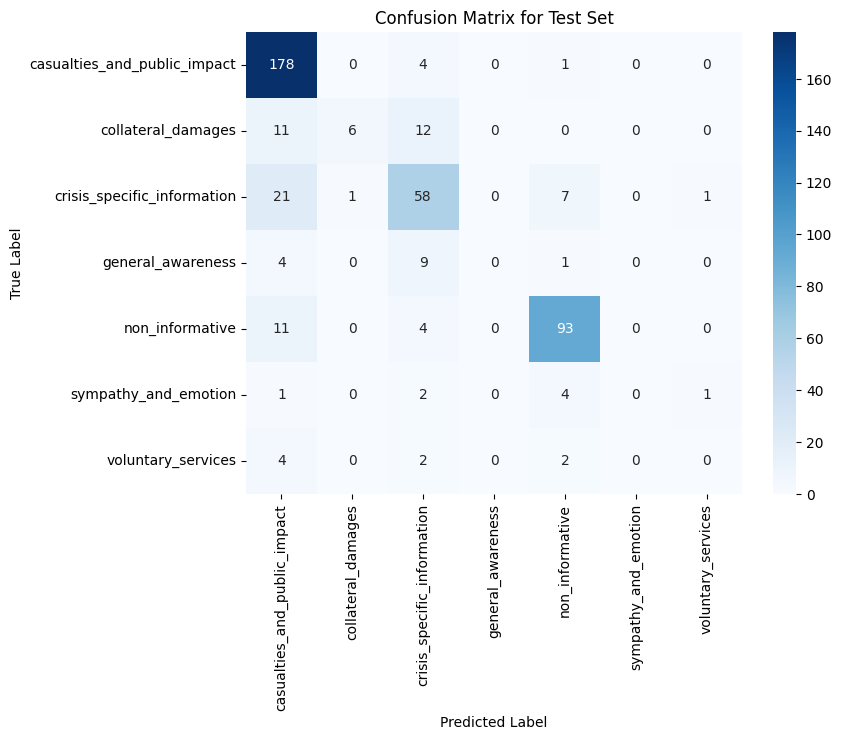

Validation Classification Report:
{'casualties_and_public_impact': {'precision': 0.7647058823529411, 'recall': 0.9680851063829787, 'f1-score': 0.8544600938967135, 'support': 188.0}, 'collateral_damages': {'precision': 1.0, 'recall': 0.16666666666666666, 'f1-score': 0.2857142857142857, 'support': 36.0}, 'crisis_specific_information': {'precision': 0.3793103448275862, 'recall': 0.515625, 'f1-score': 0.43708609271523174, 'support': 64.0}, 'general_awareness': {'precision': 1.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 15.0}, 'non_informative': {'precision': 0.8571428571428571, 'recall': 0.8823529411764706, 'f1-score': 0.8695652173913043, 'support': 102.0}, 'sympathy_and_emotion': {'precision': 1.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 17.0}, 'voluntary_services': {'precision': 1.0, 'recall': 0.06666666666666667, 'f1-score': 0.125, 'support': 15.0}, 'accuracy': 0.7139588100686499, 'macro avg': {'precision': 0.8573084406176263, 'recall': 0.37134234012754047, 'f1-score': 0.3674036699

In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

def train_classifier(texts, labels):
    vectorizer = CountVectorizer()
    classifier = MultinomialNB()
    model = make_pipeline(vectorizer, classifier)
    model.fit(texts, labels)
    return model

def categorize_texts(model, texts):
    return model.predict(texts)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.show()

def plot_roc_curve(y_test, y_score, classes):
    plt.figure(figsize=(8, 6))
    for i, class_label in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_test[:, i], y_score[:, i])
        plt.plot(fpr, tpr, label=f'{class_label} (area = {auc(fpr, tpr):.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.show()

if __name__ == "__main__":
    filepath = '/content/updated_with_relevance.csv'
    df = load_dataset(filepath)

    if 'text' not in df.columns or 'label' not in df.columns:
        raise ValueError("Dataset must contain 'text' and 'label' columns")

    texts = df['text']
    labels = df['label']

    X_temp, X_test, y_temp, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

    model = train_classifier(X_train, y_train)

    val_predictions = categorize_texts(model, X_val)
    test_predictions = categorize_texts(model, X_test)

    val_report = classification_report(y_val, val_predictions, output_dict=True, zero_division=1)
    test_report = classification_report(y_test, test_predictions, output_dict=True, zero_division=1)

    classes = sorted(set(y_train))
    y_test_binarized = label_binarize(y_test, classes=classes)
    predictions_proba = model.predict_proba(X_test)
    y_score = np.array([probs for probs in predictions_proba])

    plot_roc_curve(y_test_binarized, y_score, classes)

    cm = confusion_matrix(y_test, test_predictions, labels=classes)
    plot_confusion_matrix(cm, classes, title='Confusion Matrix for Test Set')

    print("Validation Classification Report:")
    print(val_report)

    print("\nTest Classification Report:")
    print(test_report)

    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), np.hstack(y_score), pos_label=1)
    roc_auc = auc(fpr, tpr)
    print(f"\nROC AUC: {roc_auc:.2f}")


In [ ]:
pip show transformers


Name: transformers
Version: 4.44.2
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.10/dist-packages
Requires: filelock, huggingface-hub, numpy, packaging, pyyaml, regex, requests, safetensors, tokenizers, tqdm
Required-by: 


In [ ]:
pip install --upgrade transformers


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import numpy as np
import torch
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset

def load_dataset(filepath):
    df = pd.read_csv(filepath)
    return df

def prepare_data(df):
    return df['text'].tolist(), df['label'].tolist()

class CustomDataset(Dataset):
    def __init__(self, texts, labels):
        self.texts = texts
        self.labels = labels
        self.tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(text, padding='max_length', truncation=True, return_tensors='pt', max_length=512)
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

def train_classifier(train_dataset, eval_dataset):
    model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=len(set(train_dataset.labels)))
    training_args = TrainingArguments(
        output_dir='./results',
        num_train_epochs=3,
        per_device_train_batch_size=4,
        evaluation_strategy="epoch",
        save_total_limit=2,
        logging_dir='./logs',
        logging_steps=10,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset  # using a separate validation dataset
    )
    trainer.train()
    return model

if __name__ == "__main__":
    filepath = '/content/updated_with_relevance.csv'
    df = load_dataset(filepath)

    texts, labels = prepare_data(df)

    le = LabelEncoder()
    labels = le.fit_transform(labels)

    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42)

    train_dataset = CustomDataset(X_train, y_train)
    test_dataset = CustomDataset(X_test, y_test)

    model = train_classifier(train_dataset, test_dataset)

    model.eval()
    predictions = []
    true_labels = []

    for batch in test_dataset:
        input_ids = batch['input_ids'].unsqueeze(0)
        attention_mask = batch['attention_mask'].unsqueeze(0)
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            predictions.append(torch.argmax(outputs.logits, dim=1).item())
            true_labels.append(batch['labels'].item())

    report = classification_report(true_labels, predictions, output_dict=True, zero_division=1)

    classes = sorted(set(y_train))
    y_test_binarized = label_binarize(true_labels, classes=classes)
    predictions_proba = torch.softmax(outputs.logits, dim=1).numpy()

    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), predictions_proba.ravel())
    roc_auc = auc(fpr, tpr)

    print("Classification Report:")
    print(report)

    print(f"ROC AUC: {roc_auc:.2f}")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

/usr/local/lib/python3.10/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.991400,0.797839


# New Section